# Custom Injection Scenarios

Two custom-API hooks for user-defined injection physics:

1. `dq_dz(z)` — heating rate $d(\Delta\rho/\rho)/dz$. Works in GF and PDE modes.
2. `photon_source(x, z)` — frequency-resolved $d(\Delta n)/dz$. PDE only.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from spectroxide import (
    solve, apply_style, decompose_distortion,
    mu_shape, y_shape, delta_n_to_delta_I,
)
apply_style()
_trapz = getattr(np, 'trapezoid', np.trapz)


## 1. Custom heating: GF mode

Define a Gaussian burst and compare against the built-in `single_burst` (they should agree exactly: same Green's function under the hood).


In [10]:
z_h = 8e5
sigma_z = max(z_h * 0.04, 100)
delta_rho = 1e-5

def gaussian_burst(z):
    return delta_rho / (sigma_z * np.sqrt(2*np.pi)) * np.exp(-0.5*((z-z_h)/sigma_z)**2)

# normalisation check
z_test = np.linspace(z_h - 5*sigma_z, z_h + 5*sigma_z, 10000)
print(f'integral = {_trapz([gaussian_burst(z) for z in z_test], z_test):.2e}  (target {delta_rho:.2e})')

r_custom  = solve(method='greens_function', dq_dz=gaussian_burst, z_min=1e3, z_max=3e6)
r_builtin = solve(method='greens_function', z_h=z_h, delta_rho=delta_rho)
print(f'custom  GF: mu={r_custom.mu:.4e}, y={r_custom.y:.4e}')
print(f'builtin GF: mu={r_builtin.mu:.4e}, y={r_builtin.y:.4e}')


integral = 1.00e-05  (target 1.00e-05)
custom  GF: mu=1.2349e-05, y=3.1497e-09
builtin GF: mu=1.2352e-05, y=3.0061e-09


/home/bakerem/cosmoxide/python/spectroxide/solver.py:1660: UserWarning: Analytic Green's function has 8-13% spectral shape errors in the mu-y transition region (3e4 < z < 2e5). For percent-level accuracy, use the PDE-based Green's function table:
  table = spectroxide.load_or_build_greens_table()
  dn = table.distortion_from_heating(x, dq_dz, z_min, z_max)
  result = run_single(


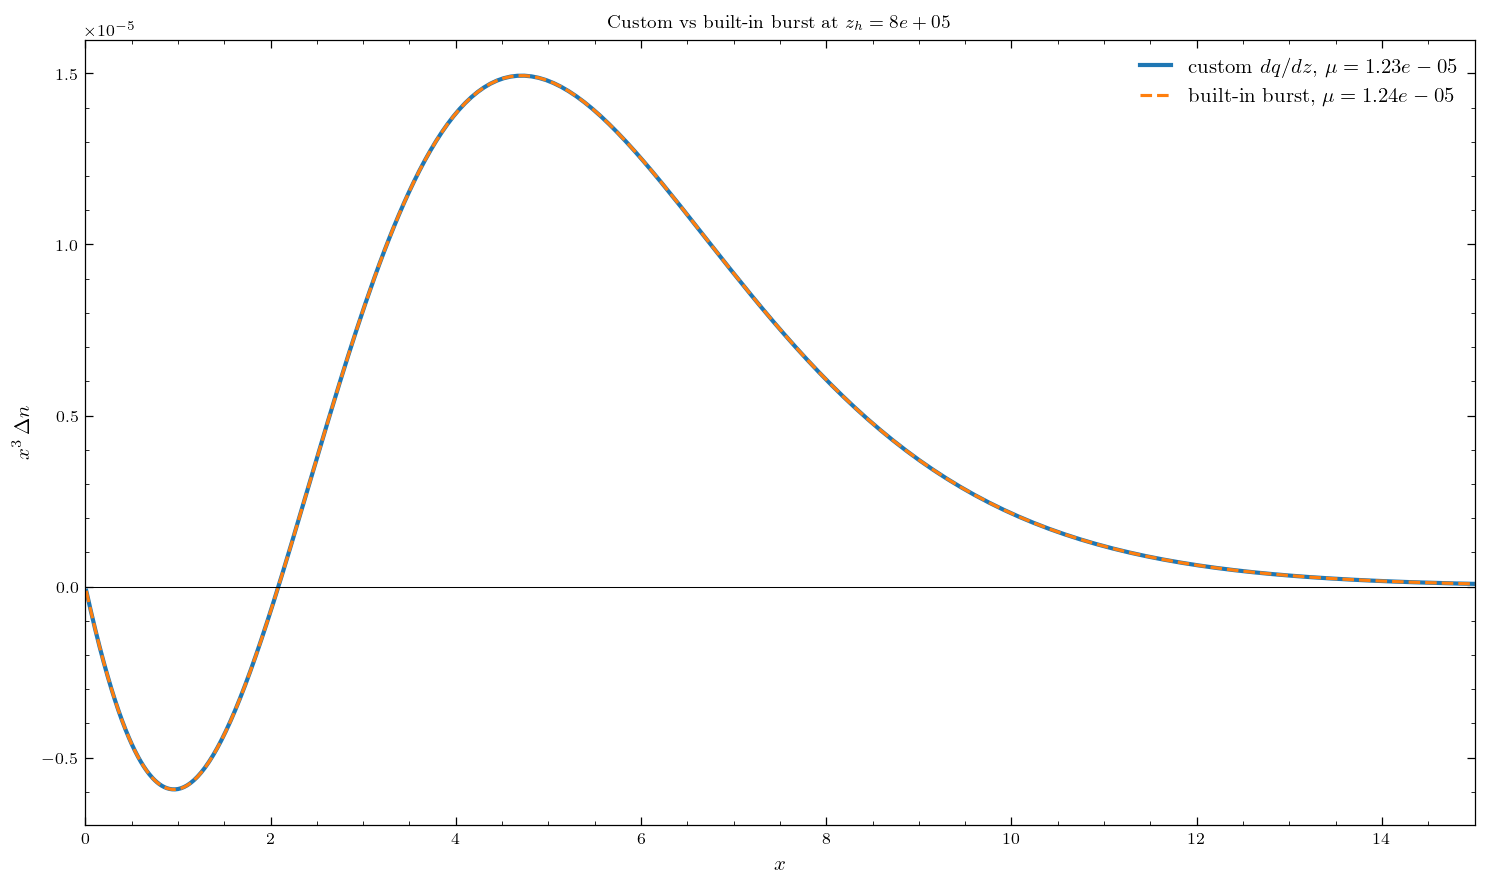

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(r_custom.x, r_custom.x**3 * r_custom.delta_n,
        'C0-', lw=2, label=rf'custom $dq/dz$, $\mu={r_custom.mu:.2e}$')
ax.plot(r_builtin.x, r_builtin.x**3 * r_builtin.delta_n,
        'C1--', lw=1.5, label=rf'built-in burst, $\mu={r_builtin.mu:.2e}$')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel=r'$x$', ylabel=r'$x^3\,\Delta n$', xlim=(0, 15),
       title=rf'Custom vs built-in burst at $z_h={z_h:.0e}$')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()


## 2. Custom heating: PDE mode

Same Gaussian, full nonlinear PDE. Solver tabulates `dq_dz` on a redshift grid internally. PDE/GF agree to ~5%.


PDE: mu=1.2452e-05, y=3.8335e-08, drho=9.9140e-06
GF : mu=1.2349e-05
PDE/GF mu = 1.008


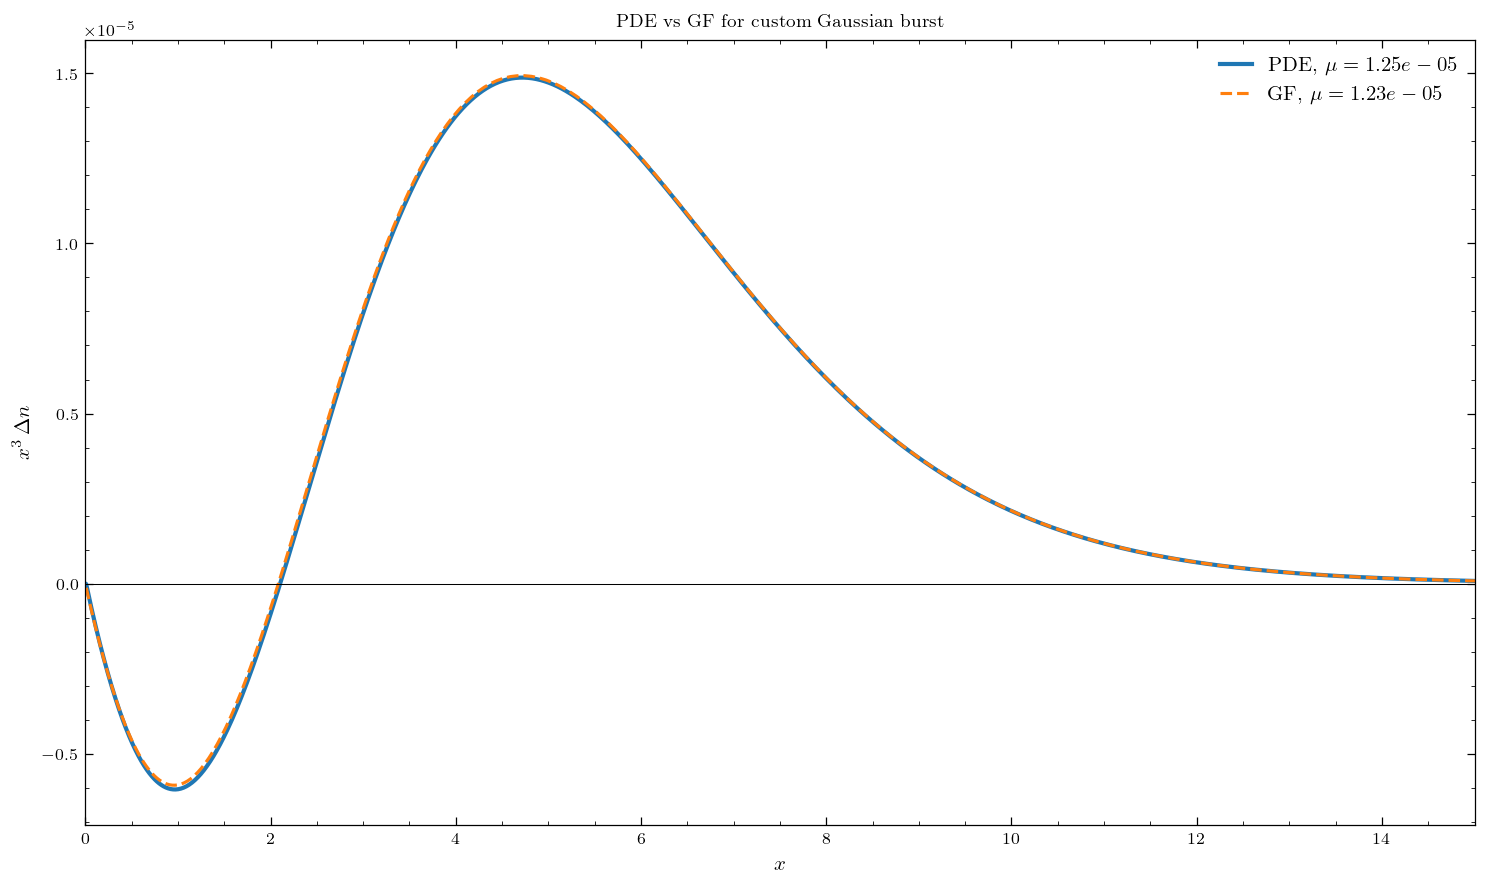

In [11]:
r_pde = solve(method='pde', dq_dz=gaussian_burst,
              z_start=z_h + 7*sigma_z, z_end=1e3,
              z_min=1e3, z_max=z_h + 7*sigma_z)
print(f'PDE: mu={r_pde.mu:.4e}, y={r_pde.y:.4e}, drho={r_pde.delta_rho_over_rho:.4e}')
print(f'GF : mu={r_custom.mu:.4e}')
print(f'PDE/GF mu = {r_pde.mu/r_custom.mu:.3f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(r_pde.x,    r_pde.x**3    * r_pde.delta_n,    'C0-',  lw=2,   label=rf'PDE, $\mu={r_pde.mu:.2e}$')
ax.plot(r_custom.x, r_custom.x**3 * r_custom.delta_n, 'C1--', lw=1.5, label=rf'GF,  $\mu={r_custom.mu:.2e}$')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel=r'$x$', ylabel=r'$x^3\,\Delta n$', xlim=(0, 15),
       title='PDE vs GF for custom Gaussian burst')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()


## 3. Power-law heating $\propto (1+z)^n$

Higher $n$ concentrates injection at higher $z$ → more $\mu$, less $y$.


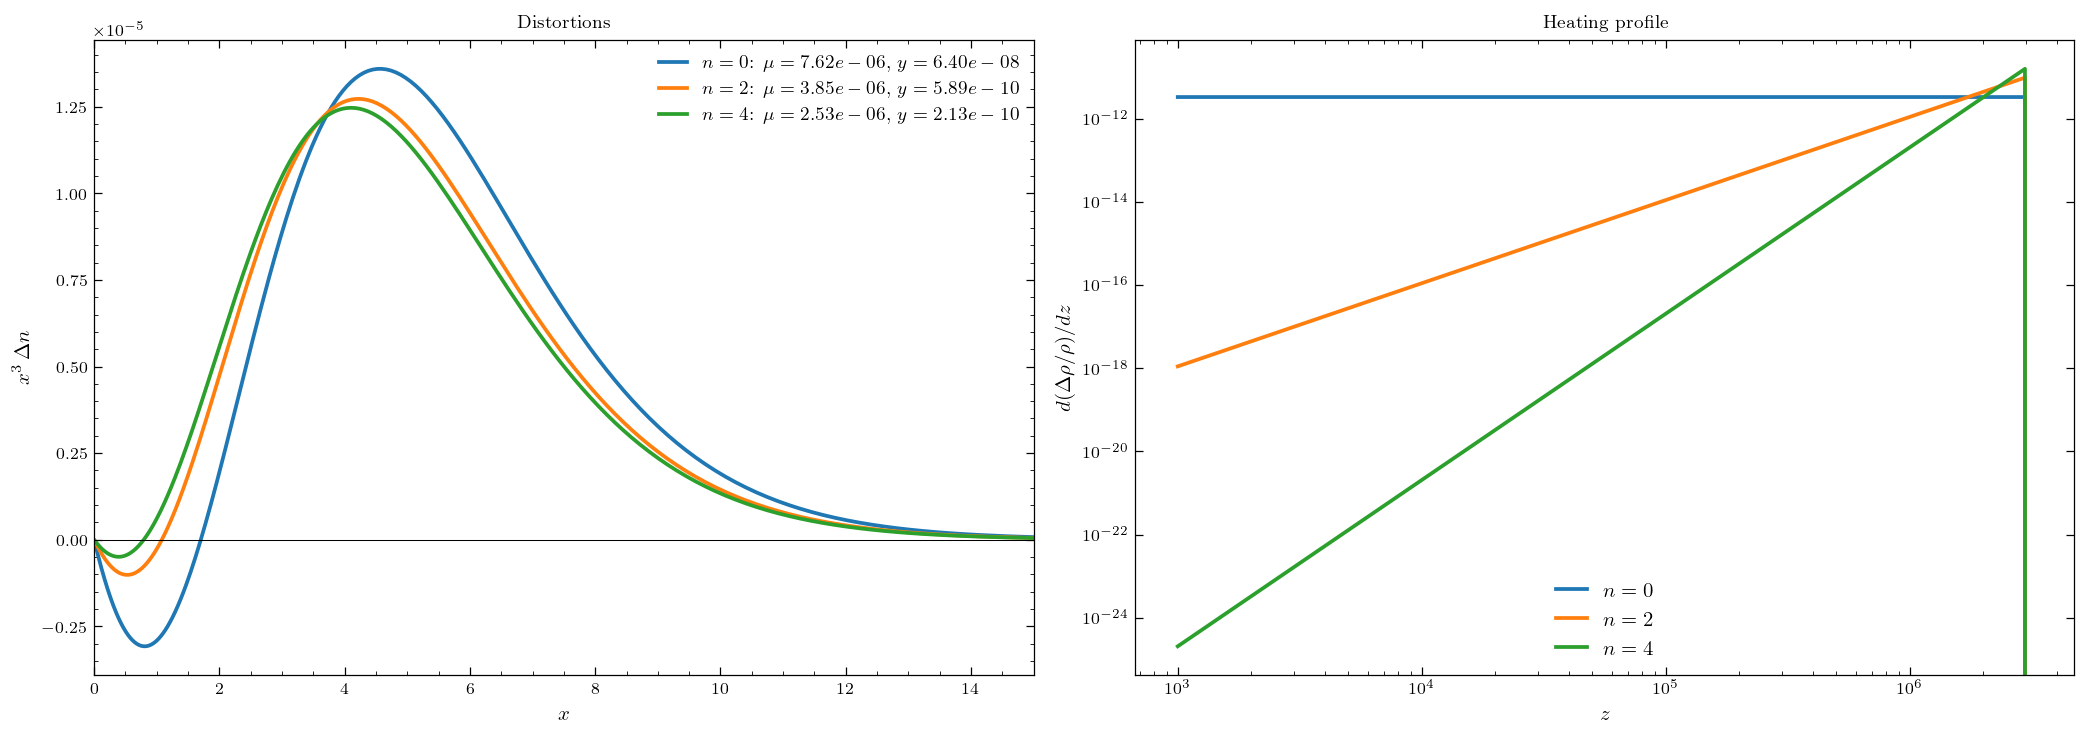

In [12]:
z_lo, z_hi = 1e3, 3e6
target_drho = 1e-5

def make_power_law(n):
    z_grid = np.logspace(np.log10(z_lo), np.log10(z_hi), 5000)
    norm = target_drho / _trapz((1+z_grid)**n, z_grid)
    def dq_dz(z):
        return 0.0 if (z < z_lo or z > z_hi) else norm * (1+z)**n
    return dq_dz

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for n_idx in (0, 2, 4):
    dq = make_power_law(n_idx)
    r = solve(method='greens_function', dq_dz=dq, z_min=z_lo, z_max=z_hi)
    ax1.plot(r.x, r.x**3 * r.delta_n, lw=1.8,
             label=rf'$n={n_idx}$: $\mu={r.mu:.2e}$, $y={r.y:.2e}$')
    z_plot = np.logspace(3, 6.5, 500)
    ax2.plot(z_plot, [dq(z) for z in z_plot], lw=1.8, label=f'$n={n_idx}$')

ax1.axhline(0, color='k', lw=0.5)
ax1.set(xlabel=r'$x$', ylabel=r'$x^3\,\Delta n$', xlim=(0, 15), title='Distortions')
ax1.legend(fontsize=9)
ax2.set(xlabel=r'$z$', ylabel=r'$d(\Delta\rho/\rho)/dz$', xscale='log', yscale='log',
        title='Heating profile')
ax2.legend(fontsize=10)
plt.tight_layout(); plt.show()


## 4. Two-burst superposition

Two Gaussians: 70% in $\mu$-era ($z=3\times10^5$), 30% in $y$-era ($z=5\times10^3$).


/home/bakerem/cosmoxide/python/spectroxide/solver.py:1660: UserWarning: Analytic Green's function has 8-13% spectral shape errors in the mu-y transition region (3e4 < z < 2e5). For percent-level accuracy, use the PDE-based Green's function table:
  table = spectroxide.load_or_build_greens_table()
  dn = table.distortion_from_heating(x, dq_dz, z_min, z_max)
  result = run_single(


mu=9.5884e-06, y=7.7598e-07, dT/T=4.4323e-06, drho/rho=1.0191e-05


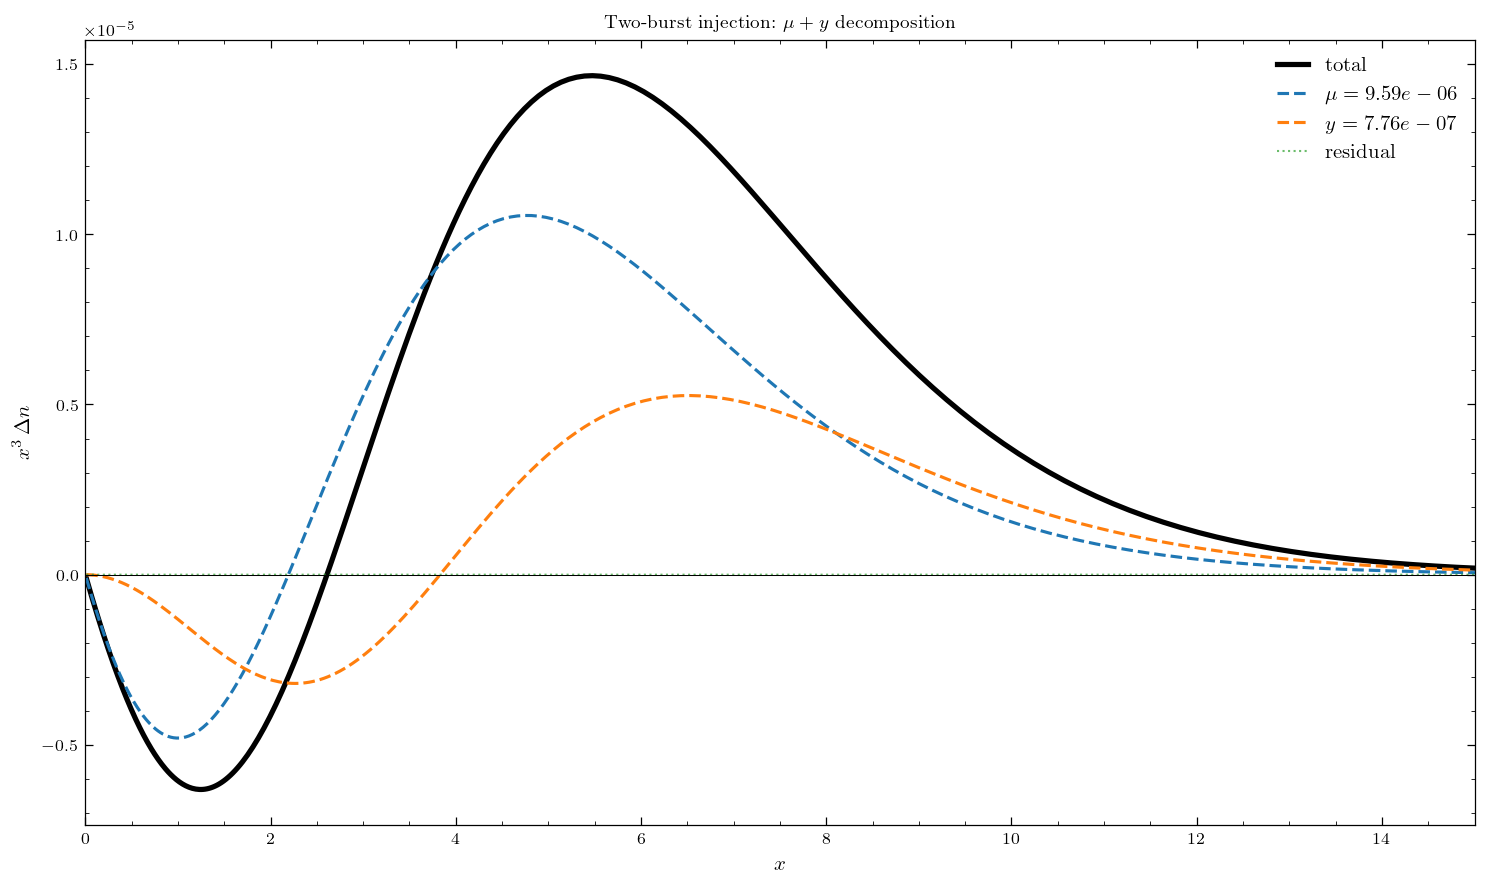

In [6]:
z1, sigma1 = 3e5, 3e5*0.04
z2, sigma2 = 5e3, max(5e3*0.04, 100)
amp1, amp2 = 0.7e-5, 0.3e-5

def two_burst(z):
    g1 = amp1/(sigma1*np.sqrt(2*np.pi)) * np.exp(-0.5*((z-z1)/sigma1)**2)
    g2 = amp2/(sigma2*np.sqrt(2*np.pi)) * np.exp(-0.5*((z-z2)/sigma2)**2)
    return g1 + g2

r2 = solve(method='greens_function', dq_dz=two_burst, z_min=1e3, z_max=3e6)
d  = decompose_distortion(r2.x, r2.delta_n)
print(f'mu={d["mu"]:.4e}, y={d["y"]:.4e}, dT/T={d["dT"]:.4e}, drho/rho={d["drho"]:.4e}')

fig, ax = plt.subplots(figsize=(10, 6))
x = r2.x
ax.plot(x, x**3 * r2.delta_n,                      'k-',   lw=2.5, label='total')
ax.plot(x, x**3 * d['mu'] * mu_shape(x),           'C0--', lw=1.5, label=rf'$\mu={d["mu"]:.2e}$')
ax.plot(x, x**3 * d['y']  * y_shape(x),            'C1--', lw=1.5, label=rf'$y={d["y"]:.2e}$')
ax.plot(x, x**3 * d['residual'],                   'C2:',  lw=1,   alpha=0.7, label='residual')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel=r'$x$', ylabel=r'$x^3\,\Delta n$', xlim=(0, 15),
       title=r'Two-burst injection: $\mu+y$ decomposition')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()


## 5. Custom photon source (PDE)

`photon_source(x, z)` returns $d(\Delta n)/dz$. Internally converted to the Boltzmann source $S = (d\Delta n/dz)\,|dz/d\tau|$.


In [7]:
z_inj = 2e5
sigma_z_phot = z_inj * 0.04
amplitude = 1e-5

def make_source(x_inj, sigma_x):
    def src(x, z):
        gx = np.exp(-0.5*((x-x_inj)/sigma_x)**2) / (sigma_x*np.sqrt(2*np.pi))
        gz = np.exp(-0.5*((z-z_inj)/sigma_z_phot)**2) / (sigma_z_phot*np.sqrt(2*np.pi))
        return amplitude * gx * gz
    return src

results = {}
for label, x_inj, sigma_x in [('soft', 0.5, 0.1), ('hard', 5.0, 0.5)]:
    r = solve(method='pde', photon_source=make_source(x_inj, sigma_x),
              z_start=z_inj + 7*sigma_z_phot, z_end=1e3,
              z_min=1e3, z_max=z_inj + 7*sigma_z_phot)
    results[label] = (x_inj, r)
    print(f'{label} (x_inj={x_inj}): mu={r.mu:.4e}, y={r.y:.4e}')


soft (x_inj=0.5): mu=-1.7626e-06, y=-4.6495e-09
hard (x_inj=5.0): mu=8.1039e-05, y=3.6354e-06


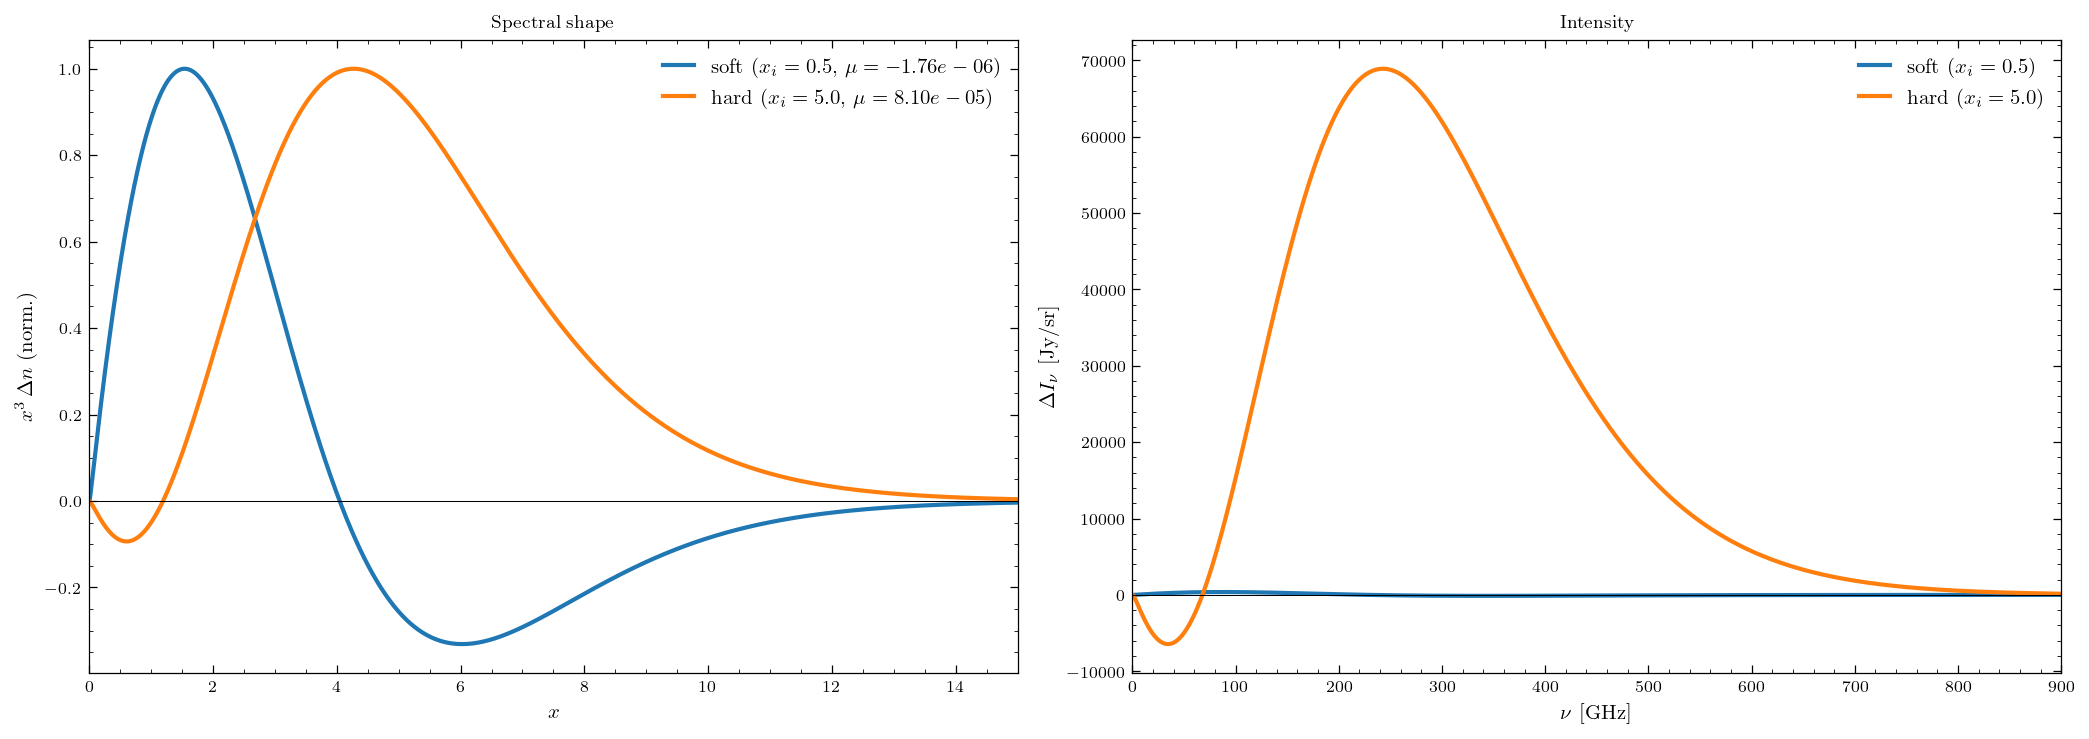

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for label, (x_inj, r), color in [('soft', results['soft'], 'C0'), ('hard', results['hard'], 'C1')]:
    dn = r.x**3 * r.delta_n
    ax1.plot(r.x, dn / np.max(np.abs(dn)), color+'-', lw=2,
             label=rf'{label} ($x_i={x_inj}$, $\mu={r.mu:.2e}$)')
    nu, dI = delta_n_to_delta_I(r.x, r.delta_n)
    ax2.plot(nu, dI, color+'-', lw=2, label=rf'{label} ($x_i={x_inj}$)')

for ax in (ax1, ax2):
    ax.axhline(0, color='k', lw=0.5); ax.legend(fontsize=10)
ax1.set(xlabel=r'$x$', ylabel=r'$x^3\,\Delta n$ (norm.)', xlim=(0, 15),
        title='Spectral shape')
ax2.set(xlabel=r'$\nu$ [GHz]', ylabel=r'$\Delta I_\nu$ [Jy/sr]', xlim=(0, 900),
        title='Intensity')
plt.tight_layout(); plt.show()


## Summary

| Mode | Call |
|---|---|
| Custom heating, GF | `solve(method='greens_function', dq_dz=f)` |
| Custom heating, PDE | `solve(method='pde', dq_dz=f)` |
| Custom photon source | `solve(method='pde', photon_source=f)` |

- `dq_dz(z)` returns $d(\Delta\rho/\rho)/dz$ (positive = heating)
- `photon_source(x, z)` returns $d(\Delta n)/dz$
- Set `z_start = z_h + 7\sigma_z` for burst-like injection
- Always verify normalisation with `np.trapezoid`

**Next:** `05_observational_constraints.ipynb` (FIRAS / PIXIE).
